### Chat Básico

**Objetivo:** Receber uma mensagem do usuário e gerar uma resposta com LLM.

Esse é o caso mais básico de uso de LLM em LangGraph.

# Atividade 06

Alunos:
* Raphael Friederich (rfrf@cesar.school)
* Maria Eduarda Alves (meas@cesar.school)

In [1]:
!pip install -U langchain langchain-openai langgraph

   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 8.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 26.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 39.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/764.4 kB ? eta -:--:--
   --------------------------------------- 764.4/764.4 kB 31.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/894.9 kB ? eta -:--:--
   --------------------------------------- 894.9/894.9 kB 10.0 MB/s eta 0:00:00

   --- ------------------------------------  3/32 [tqdm]
   --- ------------------------------------  3/32 [tqdm]
   --- ------------------------------------  3/32 [tqdm]
   ----- ----------------------------------  4/32 [regex]
   ------ ---------------------

In [1]:
import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass.getpass()

In [2]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [3]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [5]:
from typing import Annotated, TypedDict

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [6]:
def chatbot(state: State):
    messages = state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()

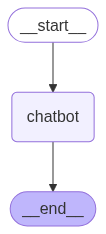

In [8]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Qual é a capital de Pernambuco?"),
    ]
})

In [10]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Qual é a capital de Pernambuco?
================================== Ai Message ==================================

A capital de Pernambuco é Recife.


### Ferramentas

In [11]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Retorna a previsão do tempo para uma localização específica."""
    return f"A previsão do tempo em {location} é ensolarada com uma temperatura de 25°C."

tools = [get_weather]

In [12]:
llm_with_tools = llm.bind_tools(tools)

In [13]:
result = llm_with_tools.invoke("qual é a previsão do tempo em Recife?")
print(result)

content='' additional_kwargs={'tool_calls': [{'id': 'call_BjievbVmFAszt6BwbR9Pe2Gy', 'function': {'arguments': '{"location":"Recife"}', 'name': 'get_weather'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 57, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-Byp4JsYDG3netf6xLrwvo6ytT1deI', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='run--71d70da5-6925-40fb-ad3e-d03c5189c50d-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'Recife'}, 'id': 'call_BjievbVmFAszt6BwbR9Pe2Gy', 'type': 'tool_call'}] usage_metadata={'input_tokens': 57, 'output_tokens': 15, 'total_tokens': 72, 'input_token_details': {'audio': 0, 

In [14]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition

def chatbot(state: State):
    messages = state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

tool_node = ToolNode(tools=tools)

In [16]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

builder.add_edge("tools", "chatbot")
builder.add_edge(START, "chatbot")

graph = builder.compile()

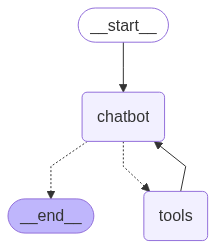

In [17]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [18]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Qual é a previsão do tempo em Recife?"),
    ]
})

In [19]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Qual é a previsão do tempo em Recife?
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_qiNFoQ9yksLikEcJOzXBV6Dk)
 Call ID: call_qiNFoQ9yksLikEcJOzXBV6Dk
  Args:
    location: Recife
================================= Tool Message =================================
Name: get_weather

A previsão do tempo em Recife é ensolarada com uma temperatura de 25°C.
================================== Ai Message ==================================

A previsão do tempo em Recife é ensolarada, com uma temperatura de 25°C.


## Exercícios

### Exercício 1
Crie um agente que escreva e leia arquivos de texto com o conteúdo solicitado pelo usuário.

In [5]:
from langchain.tools import tool
# escrever e ler arquivos

@tool
def write_file(filename:str,content:str) -> str:
  """Escreva um arquivo"""
  with open(filename, 'w') as f:
    f.write(content)

@tool
def read_file(filename:str) -> str:
  """Leia o conteúdo do arquivo"""
  with open(filename, 'r') as f:
    return f.read()

tools = [read_file, write_file]

In [6]:
from typing import Annotated, TypedDict

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
from langgraph.prebuilt import ToolNode, tools_condition

def chatbot(state: State):
    messages = state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

tool_node = ToolNode(tools=tools)

In [8]:
llm_with_tools = llm.bind_tools(tools)

In [10]:
result = llm_with_tools.invoke(f"Crie um arquivo que contenha piadas.")
print(result)

content='' additional_kwargs={'tool_calls': [{'id': 'call_lkpQGzp97TZUsi6i0HhsAR1a', 'function': {'arguments': '{"filename":"piadas.txt","content":"1. Por que o livro de matemática se suicidou?\\n   Porque ele tinha muitos problemas.\\n\\n2. O que o zero disse para o oito?\\n   Belo cinto!\\n\\n3. Por que a banana foi ao médico?\\n   Porque não estava se sentindo bem!\\n\\n4. O que acontece quando um matemático entra em uma briga?\\n   Ele resolve a questão!\\n\\n5. Como o oceanógrafo se despede?\\n   Até logo, mar! "}', 'name': 'write_file'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 77, 'total_tokens': 202, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62a23a81ef', 'id': 'chatcmpl-BypB5ux

In [11]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    messages = state["messages"]
    return {"messages": [llm_with_tools.invoke(messages)]}

tool_node = ToolNode(tools=tools)

In [12]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

builder.add_edge("tools", "chatbot")
builder.add_edge(START, "chatbot")

graph = builder.compile()

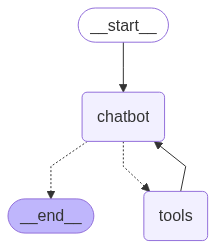

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [14]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Crie um arquivo que contenha piadas."),
    ]
})

In [15]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Crie um arquivo que contenha piadas.
================================== Ai Message ==================================
Tool Calls:
  write_file (call_4s72nL7GN2s6uyZ9S5kE7Vwi)
 Call ID: call_4s72nL7GN2s6uyZ9S5kE7Vwi
  Args:
    filename: piadas.txt
    content: 1. Por que o computador foi ao médico? Porque ele tinha um vírus!

2. O que o zero disse para o oito? Que cinto legal!

3. Por que o livro de matemática se suicidou? Porque ele tinha muitos problemas.

4. Qual é a fruta que nunca cai do pé? A tangerina, porque ela sempre está no suco!

5. O que é um vegetariano que come carne? Um ex-vegetariano!
================================= Tool Message =================================
Name: write_file

null
================================== Ai Message ==================================

O arquivo com piadas foi criado com sucesso! Se precisar de mais alguma coisa, é só avisar.


In [16]:
response = graph.invoke({
    "messages": [
        HumanMessage(content="Leia o conteúdo do piadas.txt"),
    ]
})

In [17]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Leia o conteúdo do piadas.txt
================================== Ai Message ==================================
Tool Calls:
  read_file (call_Qy51KPt577oYpD8sfXSsafJI)
 Call ID: call_Qy51KPt577oYpD8sfXSsafJI
  Args:
    filename: piadas.txt
================================= Tool Message =================================
Name: read_file

1. Por que o computador foi ao médico? Porque ele tinha um vírus!

2. O que o zero disse para o oito? Que cinto legal!

3. Por que o livro de matemática se suicidou? Porque ele tinha muitos problemas.

4. Qual é a fruta que nunca cai do pé? A tangerina, porque ela sempre está no suco!

5. O que é um vegetariano que come carne? Um ex-vegetariano!
================================== Ai Message ==================================

Aqui estão as piadas do arquivo "piadas.txt":

1. Por que o computador foi ao médico? Porque ele tinha um vírus!

2. O que o zero disse para o oito? Q